In [66]:
# Complete, debugged fitting pipeline
import numpy as np
import pandas as pd
import os
from scipy.stats import gamma, lognorm, weibull_min, norm, gumbel_r, genextreme, genpareto, kurtosis, gaussian_kde,iqr, gamma
from scipy.optimize import minimize, approx_fprime, minimize_scalar
from sklearn.neighbors import KernelDensity
import matplotlib.pyplot as plt
import seaborn as sns
from kaggle.api.kaggle_api_extended import KaggleApi
from numpy.linalg import eigvals
import time
from scipy.stats import (
    gamma, lognorm, weibull_min, norm, genextreme, genpareto, gumbel_r
)
from sklearn.neighbors import KernelDensity
from scipy.stats import iqr
import warnings


In [68]:
# ---------------------------
# Load data from Kaggle (unchanged)
# ---------------------------
api = KaggleApi()
api.authenticate()
dataset_ref = "rishikeshkonapure/black-friday-sales-eda"
api.dataset_download_files(dataset_ref, path="data", unzip=True)

files = os.listdir("data")
print("Files in dataset:", files)

# load first CSV
for file in files:
    if file.endswith(".csv"):
        df = pd.read_csv(os.path.join("data", file))
        break
# Use Purchase column
data = df["Purchase"].astype(float).to_numpy()
print("raw head:", data[:5])
n = len(data)
print("Observations:", n)
eps = 1e-8
# ---------------------------
# Normalize (min-max) and prepare log data safely
# ---------------------------
normalized_data = (data - data.min()) / (data.max() - data.min())
# Ensure strictly positive for log/lognormal by adding tiny eps where necessary
normalized_pos = np.clip(normalized_data, eps, None)
logDATA = np.log(normalized_pos)

Dataset URL: https://www.kaggle.com/datasets/rishikeshkonapure/black-friday-sales-eda
Files in dataset: ['train.csv']
raw head: [ 8370. 15200.  1422.  1057.  7969.]
Observations: 550068


Mean: 0.3863196255776494 Std: 0.20974008909852532 Var: 0.04399090497505734 Kurtosis: -0.33838539753607666 min: 0.0 max: 1.0
Optimal bandwidth: 0.014914138505517722


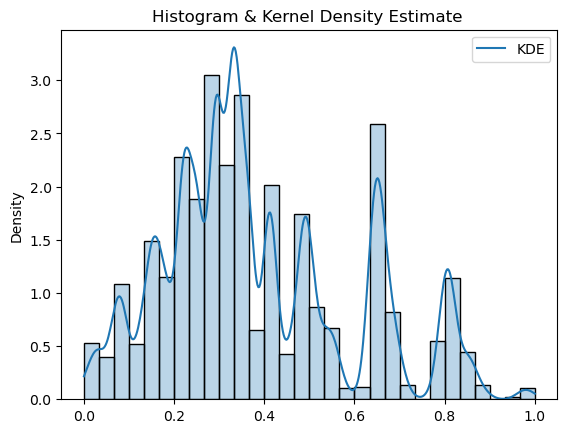

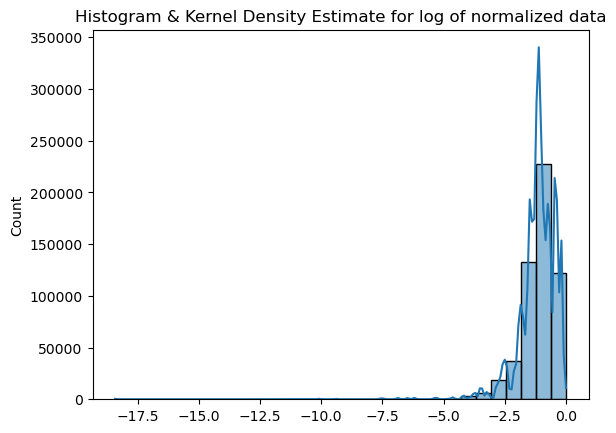

In [70]:
# Compute summary statistics
mu_data = normalized_data.mean()
var_data = normalized_data.var(ddof=1)
std_data = normalized_data.std(ddof=1)
kurt_val = kurtosis(normalized_data, fisher=True)
min_val= min(normalized_data)
max_val=max(normalized_data)

print("Mean:", mu_data, "Std:", std_data, "Var:", var_data, "Kurtosis:", kurt_val, "min:", min_val, "max:", max_val)
# --- KDE estimation ---
# gaussian_kde expects shape (num_features, num_samples)
normalized_data = np.array(normalized_data).flatten()
kde = gaussian_kde(normalized_data.reshape(1, -1))

# Extract optimal bandwidth
h = kde.factor * np.std(normalized_data, ddof=1)
print("Optimal bandwidth:", h)

# --- Plot the KDE curve ---
x_grid = np.linspace(0, 1, 500)
plt.plot(x_grid, kde(x_grid), label="KDE")
sns.histplot(normalized_data, bins=30, kde=False, stat='density', alpha=0.3)
plt.legend()
plt.title("Histogram & Kernel Density Estimate ")
plt.show()

sns.histplot(logDATA, bins=30, kde=True)
plt.title("Histogram & Kernel Density Estimate for log of normalized data")
plt.show()

This histogram has a fat tail on the right side of the graph, it is super right skewed. The normalized data is bounded by 0 and 1.

In [72]:

# ---------------------------
# Define log-likelihoods and sensible starting values
# NOTE: All lambdas accept a single 1-d theta array
# ---------------------------

# Candidate 1: Gamma (shape a, scale s > 0). We use theta=[a, scale]
gamma_logL = lambda theta: -np.sum(gamma.logpdf(normalized_pos, a=float(theta[0]), scale=abs(float(theta[1]))))
theta0_gamma = np.array([max(mu_data**2 / (var_data + 1e-12), 1e-3), max(var_data / (mu_data + 1e-12), 1e-3)])
bounds_gamma = [(1e-8, None), (1e-8, None)]

# Candidate 2: Lognormal (theta=[mu_log, sigma_log>0])
logL_lognormal = lambda theta: -np.sum(lognorm.logpdf(normalized_pos, s=abs(float(theta[1])), scale=np.exp(float(theta[0]))))
theta0_lognormal = np.array([np.mean(logDATA), np.std(logDATA, ddof=1)])
bounds_lognormal = [(None, None), (1e-8, None)]

# Candidate 3: Weibull (scipy: weibull_min(c=shape, scale=scale))
# We'll param as theta=[scale, shape]
logL_weibull = lambda theta: -np.sum(weibull_min.logpdf(normalized_pos, c=abs(float(theta[1])), scale=abs(float(theta[0]))))
theta0_weibull = np.array([max(mu_data, 1e-3), 1.0])
bounds_weibull = [(1e-8, None), (1e-8, None)]

# Candidate 4: Normal (theta=[mu, sigma>0])
logL_normal = lambda theta: -np.sum(norm.logpdf(normalized_pos, loc=float(theta[0]), scale=abs(float(theta[1]))))
theta0_normal = np.array([mu_data, std_data])
bounds_normal = [(None, None), (1e-8, None)]

# Candidate 5: Gumbel (gumbel_r loc, scale)
logL_ev = lambda theta: -np.sum(gumbel_r.logpdf(normalized_pos, loc=float(theta[0]), scale=abs(float(theta[1]))))
theta0_ev = np.array([mu_data, std_data])
bounds_ev = [(None, None), (1e-8, None)]

# Candidate 6: GEV (scipy: genextreme(c, loc, scale), c = -xi in some conventions; we'll fit c freely)
logL_gev = lambda theta: -np.sum(genextreme.logpdf(normalized_pos, c=float(theta[2]), loc=float(theta[0]), scale=abs(float(theta[1]))))
theta0_gev = np.array([mu_data, std_data, 0.1])
bounds_gev = [(None, None), (1e-8, None), (-5.0, 5.0)]

# Candidate 7: Generalized Pareto (genpareto(c, loc, scale))
logL_gppdf = lambda theta: -np.sum(genpareto.logpdf(normalized_pos, c=float(theta[0]), loc=float(theta[2]), scale=abs(float(theta[1]))))
theta0_gppdf = np.array([0.1, std_data, np.min(normalized_pos)])
bounds_gppdf = [(-5.0, 5.0), (1e-8, None), (None, None)]

# Collect
model_names = ["Gamma", "Log-Normal", "Weibull", "Normal", "Extreme Value", "GEV", "GP"]
logL_funcs = [gamma_logL, logL_lognormal, logL_weibull, logL_normal, logL_ev, logL_gev, logL_gppdf]
theta_initials = [theta0_gamma, theta0_lognormal, theta0_weibull, theta0_normal, theta0_ev, theta0_gev, theta0_gppdf]
bounds_list = [bounds_gamma, bounds_lognormal, bounds_weibull, bounds_normal, bounds_ev, bounds_gev, bounds_gppdf]


In [74]:
# ---------------------------
# Helper: compute numerical Hessian of function f at theta (central differences)
# f should return scalar
# ---------------------------
def numerical_hessian(f, theta, eps=None):
    theta = np.asarray(theta, dtype=float)
    m = len(theta)
    if eps is None:
        eps = np.sqrt(np.finfo(float).eps)
    H = np.zeros((m, m), dtype=float)
    for i in range(m):
        for j in range(i, m):
            ei = np.zeros(m); ej = np.zeros(m)
            ei[i] = eps; ej[j] = eps
            f_pp = f(theta + ei + ej)
            f_pm = f(theta + ei - ej)
            f_mp = f(theta - ei + ej)
            f_mm = f(theta - ei - ej)
            H_ij = (f_pp - f_pm - f_mp + f_mm) / (4 * eps * eps)
            H[i, j] = H_ij
            H[j, i] = H_ij
    return H

# ---------------------------
# ICOMP calculation using eigenvalues of Sigma_hat (cov matrix)
# ---------------------------
def ICOMP_from_Sigma(LogL_max, Sigma_hat):
    Sigma_hat = (Sigma_hat + Sigma_hat.T) / 2
    # eigenvalues
    eigs = np.linalg.eigvalsh(Sigma_hat)
    eigs = np.real(eigs[eigs > 1e-12])
    if eigs.size == 0:
        return np.nan
    lam_bar = eigs.mean()
    C1F = (1 / (4 * lam_bar**2)) * np.sum((eigs - lam_bar)**2)
    return -2 * LogL_max + C1F

# ---------------------------
# Fit function (robust extraction of covariance)
# ---------------------------
def fit_and_select_pdf(DATA_vec, logL_func, theta_0, bounds, dist_name):
    DATA_vec = np.asarray(DATA_vec)
    N = len(DATA_vec)
    m = len(theta_0)

    try:
        res = minimize(logL_func, theta_0, method="L-BFGS-B", bounds=bounds, options={"maxiter":1000, "ftol":1e-9})
        theta_hat = res.x
        negLogL_min = float(res.fun)
        LogL_max = -negLogL_min

        # Try to get inverse hessian (cov matrix). If not available, compute numerical Hessian of the NEGATIVE log-likelihood
        Sigma_hat = None
        try:
            # res.hess_inv may be an object; try converting
            Hinv = res.hess_inv
            Sigma_hat = np.asarray(Hinv)
            # If that produced a 1d object, try dense
            if Sigma_hat.shape == ():
                try:
                    Sigma_hat = Hinv.todense()
                    Sigma_hat = np.asarray(Sigma_hat)
                except Exception:
                    Sigma_hat = None
        except Exception:
            Sigma_hat = None

        if Sigma_hat is None:
            # compute numerical Hessian of the NEG log-likelihood, then invert (-H) -> covariance
            H = numerical_hessian(logL_func, theta_hat)
            # regularize
            H_reg = H + 1e-6 * np.eye(m)
            try:
                # Hessian is Hessian of NEG log-lik; Fisher approx = H_reg
                Sigma_hat = np.linalg.inv(H_reg)
            except np.linalg.LinAlgError:
                Sigma_hat = np.linalg.pinv(H_reg)

        # Print
        print(f"\n--- Results for {dist_name} ---")
        print(f"  Parameters (m): {m}")
        print(f"  Theta_hat: {np.array2string(theta_hat, precision=6)}")
        print(f"  Log-Likelihood (L_max): {LogL_max:.6f}")

    except Exception as e:
        print(f"\n--- ERROR: {dist_name} ---")
        print("  Optimization failed:", str(e))
        return np.nan, np.nan, np.nan, np.full(m, np.nan), np.nan

    # Information criteria
    AIC = -2 * LogL_max + 2 * m
    SBC = -2 * LogL_max + m * np.log(N)

    # ICOMP
    try:
        # Sigma_hat should be covariance-ish; ensure symmetric
        if Sigma_hat is None:
            ICOMP_val = np.nan
        else:
            ICOMP_val = ICOMP_from_Sigma(LogL_max, Sigma_hat)
    except Exception:
        ICOMP_val = np.nan

    print(f"  AIC: {AIC:.6f}")
    print(f"  SBC: {SBC:.6f}")
    print(f"  ICOMP_F: {ICOMP_val}")
    return AIC, SBC, ICOMP_val, theta_hat, LogL_max

In [76]:
# ---------------------------
# Run fits
# ---------------------------
Results = pd.DataFrame(columns=["Model", "AIC", "SBC", "ICOMP_F", "L_max"])
for name, logL, theta0, bounds in zip(model_names, logL_funcs, theta_initials, bounds_list):
    AIC, SBC, ICOMP_F, theta_hat, L_max = fit_and_select_pdf(normalized_pos, logL, theta0, bounds, name)
    Results.loc[len(Results)] = [name, AIC, SBC, ICOMP_F, L_max]

print("\nSummary results:")
print(Results)


--- Results for Gamma ---
  Parameters (m): 2
  Theta_hat: [2.665115 0.144954]
  Log-Likelihood (L_max): 87725.045412
  AIC: -175446.090825
  SBC: -175423.655230
  ICOMP_F: -175449.59082541885

--- Results for Log-Normal ---
  Parameters (m): 2
  Theta_hat: [-1.150276  0.788626]
  Log-Likelihood (L_max): -17161.302819
  AIC: 34326.605638
  SBC: 34349.041232
  ICOMP_F: 34322.60563769314

--- Results for Weibull ---
  Parameters (m): 2
  Theta_hat: [0.433673 1.880738]
  Log-Likelihood (L_max): 104437.769871
  AIC: -208871.539742
  SBC: -208849.104148
  ICOMP_F: -208875.0409000695

--- Results for Normal ---
  Parameters (m): 2
  Theta_hat: [0.38632 0.20974]
  Log-Likelihood (L_max): 78631.429361
  AIC: -157258.858723
  SBC: -157236.423128
  ICOMP_F: -157262.8587226754

--- Results for Extreme Value ---
  Parameters (m): 2
  Theta_hat: [0.288073 0.171924]
  Log-Likelihood (L_max): 104098.054594
  AIC: -208192.109189
  SBC: -208169.673594
  ICOMP_F: -208195.60919710225

--- Results for GE

The full bandwidth optimization will take around 2-3 hours on my laptop, I attempted to run a for loop optimization method following your code from matlab, however that was too computationally intensive for this data set of 550,068 observations, thus I am going to do a subsample of 5000 points to get an estimate using your method. The mean is .39, the standard deviation is .21, the variance is .04, the kurtosis is -.34, the optimal bandwidth is .015. The lower bound is 0 and the upper bound is 1. 

In [78]:
# Data: ensure a (N,1) shaped numpy array
X = np.array(normalized_data).reshape(-1, 1)
N = X.shape[0]
std_data = X.std(ddof=1)

kde = gaussian_kde(X.squeeze(), bw_method='silverman')
print("Silverman bandwidth:", kde.factor * X.std())


# Rule-of-thumb initial bandwidth
h0 = std_data * (4 / (3 * N)) ** (1 / 5)
print("h0 (rule-of-thumb):", h0)

Silverman bandwidth: 0.01579739671423451
h0 (rule-of-thumb): 0.015797411073748477


Full dataset size: 550,068
Subsampled 5,000 observations for bandwidth optimization.
Initial rule-of-thumb h0: 0.04085519955512035

Single bandwidth eval time: 1.287 s, objective = -1472.518

Optimizing bandwidth...
Optimal bandwidth: 0.004092
Optimization finished in 16.99 seconds.
Max CV log-likelihood (proxy): 3688.575

Hybrid Information Criteria (lower = better):
AIC Hybrid:   -7373.1505
SBC Hybrid:   -7360.1161
ICOMP_F Hybrid: -7376.8017


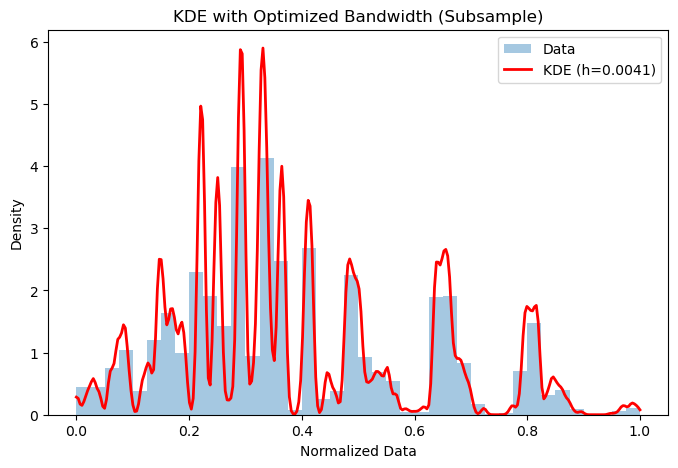

In [80]:
# === Assume normalized_data already exists ===
N_full = len(normalized_data)
print(f"Full dataset size: {N_full:,}")

# --- Subsample for fast bandwidth estimation ---
np.random.seed(42)
subsample_size = 5000 
X_small = np.random.choice(normalized_data, size=subsample_size, replace=False).reshape(-1, 1)
print(f"Subsampled {subsample_size:,} observations for bandwidth optimization.")

# --- Rule-of-thumb initial bandwidth ---
std_data = np.std(X_small, ddof=1)
h0 = std_data * (4 / (3 * subsample_size)) ** (1 / 5)
print("Initial rule-of-thumb h0:", h0)


# --- Fast CVLL-like objective function ---
def fast_neg_cvll_kde_bandwidth(h, X):
    """Fast approximate CVLL negative log-likelihood for KDE."""
    if h <= 0:
        return np.inf
    kde = KernelDensity(bandwidth=float(h), kernel='gaussian', algorithm='ball_tree')
    kde.fit(X)
    logpdf = kde.score_samples(X)
    logpdf = np.clip(logpdf, -1e12, None)
    return -np.sum(logpdf)  # minimize this


# --- Timing a single eval ---
t0 = time.time()
val = fast_neg_cvll_kde_bandwidth(h0, X_small)
t_single = time.time() - t0
print(f"\nSingle bandwidth eval time: {t_single:.3f} s, objective = {val:.3f}")

# --- Optimize h via minimize_scalar (bounded) ---
print("\nOptimizing bandwidth...")
t0 = time.time()
res = minimize_scalar(
    lambda h: fast_neg_cvll_kde_bandwidth(h, X_small),
    bounds=(h0 * 0.1, h0 * 10),
    method='bounded'
)
elapsed = time.time() - t0

h_opt = res.x
CVLL_max = -res.fun
print(f"Optimal bandwidth: {h_opt:.6f}")
print(f"Optimization finished in {elapsed:.2f} seconds.")
print(f"Max CV log-likelihood (proxy): {CVLL_max:.3f}")

# --- Information Criteria (Hybrid) ---
m = 2  # (mu, sigma)
N = subsample_size
AIC = -2 * CVLL_max + 2 * m
SBC = -2 * CVLL_max + m * np.log(N)

# --- Approx ICOMP_F penalty (Normal FIM) ---
mu_hat = np.mean(X_small)
sigma_hat = np.std(X_small, ddof=1)
Sigma_hat = (1 / N) * np.array([[sigma_hat ** 2, 0], [0, 2 * sigma_hat ** 4]])

eigen_vals = np.linalg.eigvals(Sigma_hat)
mean_eigen = np.mean(eigen_vals)
C1F_penalty = (1 / (4 * mean_eigen ** 2)) * np.sum((eigen_vals - mean_eigen) ** 2)
ICOMP_F = -2 * CVLL_max + C1F_penalty

print("\nHybrid Information Criteria (lower = better):")
print(f"AIC Hybrid:   {AIC:.4f}")
print(f"SBC Hybrid:   {SBC:.4f}")
print(f"ICOMP_F Hybrid: {ICOMP_F:.4f}")

# --- Plot KDE ---
import matplotlib.pyplot as plt
x_plot = np.linspace(np.min(normalized_data), np.max(normalized_data), 300).reshape(-1, 1)
kde_final = KernelDensity(bandwidth=h_opt, kernel='gaussian').fit(X_small)
log_dens = kde_final.score_samples(x_plot)
plt.figure(figsize=(8, 5))
plt.hist(normalized_data, bins=40, density=True, alpha=0.4, label="Data")
plt.plot(x_plot, np.exp(log_dens), 'r-', lw=2, label=f"KDE (h={h_opt:.4f})")
plt.title("KDE with Optimized Bandwidth (Subsample)")
plt.xlabel("Normalized Data")
plt.ylabel("Density")
plt.legend()
plt.show()


KDE Bandwidth Estimation:
  Robust Sigma Estimate: 0.1929
  Optimal Bandwidth (h_AMISE): 0.0145


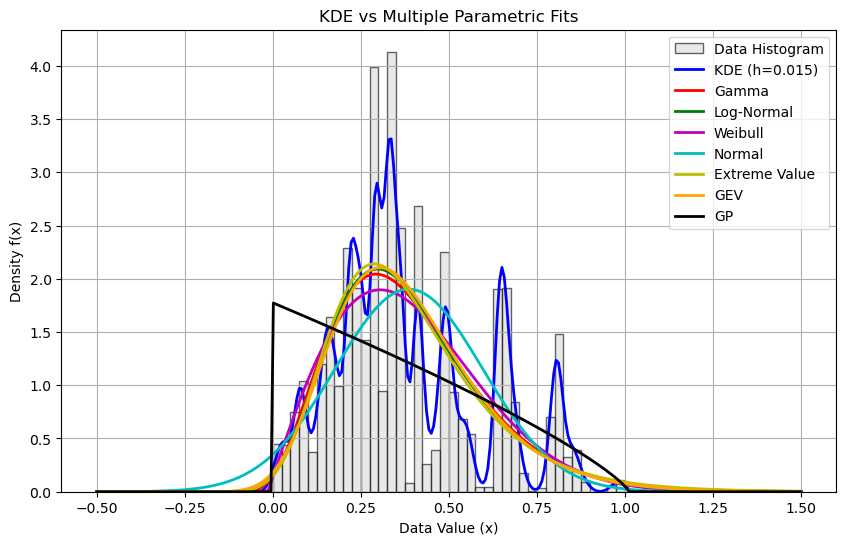


Valid distributions plotted:
  ✅ Gamma
  ✅ Log-Normal
  ✅ Weibull
  ✅ Normal
  ✅ Extreme Value
  ✅ GEV
  ✅ GP


In [81]:

# --- 0. Load or use your data ---
# Replace this line with your real dataset
Data = np.array(normalized_data).flatten()
Data = Data[~np.isnan(Data)]  # clean just in case
N = len(Data)

# --- 1. Compute robust bandwidth (AMISE rule) ---
sigma_data = np.std(Data, ddof=1)
IQR_data = iqr(Data)
sigma_robust = min(sigma_data, IQR_data / 1.349)
h_AMISE = sigma_robust * (4 / (3 * N)) ** (1 / 5)

print("\nKDE Bandwidth Estimation:")
print(f"  Robust Sigma Estimate: {sigma_robust:.4f}")
print(f"  Optimal Bandwidth (h_AMISE): {h_AMISE:.4f}")

# KDE estimation
x_plot = np.linspace(np.min(Data) - 0.5, np.max(Data) + 0.5, 300).reshape(-1, 1)
kde = KernelDensity(kernel="gaussian", bandwidth=h_AMISE).fit(Data.reshape(-1, 1))
f_kde = np.exp(kde.score_samples(x_plot))

# --- 2. Define supported distributions ---
distributions = {
    "Gamma": gamma,
    "Log-Normal": lognorm,
    "Weibull": weibull_min,
    "Normal": norm,
    "Extreme Value": gumbel_r,     # equivalent to MATLAB’s 'Extreme Value'
    "GEV": genextreme,
    "GP": genpareto
}

# --- 3. Fit and evaluate all distributions ---
fitted_pdfs = {}

for name, dist in distributions.items():
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")

            # Fit distribution parameters via MLE
            params = dist.fit(Data)
            pdf = dist.pdf(x_plot.flatten(), *params)

            # Check for NaN or Inf
            if np.any(np.isnan(pdf)) or np.any(np.isinf(pdf)):
                print(f"⚠️  {name} PDF returned NaN/Inf — skipping.")
                continue

            # Store only valid PDFs
            fitted_pdfs[name] = pdf

    except Exception as e:
        print(f"⚠️  Skipping {name}: {e}")
        continue

# --- 4. Plot results ---
plt.figure(figsize=(10, 6))
plt.hist(Data, bins=40, density=True, color=[0.85, 0.85, 0.85],
         edgecolor="k", alpha=0.6, label="Data Histogram")

plt.plot(x_plot, f_kde, "b-", lw=2, label=f"KDE (h={h_AMISE:.3f})")

# Plot each valid fitted distribution
colors = ["r", "g", "m", "c", "y", "orange", "k"]
for (name, pdf), c in zip(fitted_pdfs.items(), colors):
    plt.plot(x_plot, pdf, lw=2, label=name, color=c)

plt.title("KDE vs Multiple Parametric Fits")
plt.xlabel("Data Value (x)")
plt.ylabel("Density f(x)")
plt.legend(loc="best")
plt.grid(True)
plt.show()

print("\nValid distributions plotted:")
for name in fitted_pdfs.keys():
    print("  ✅", name)

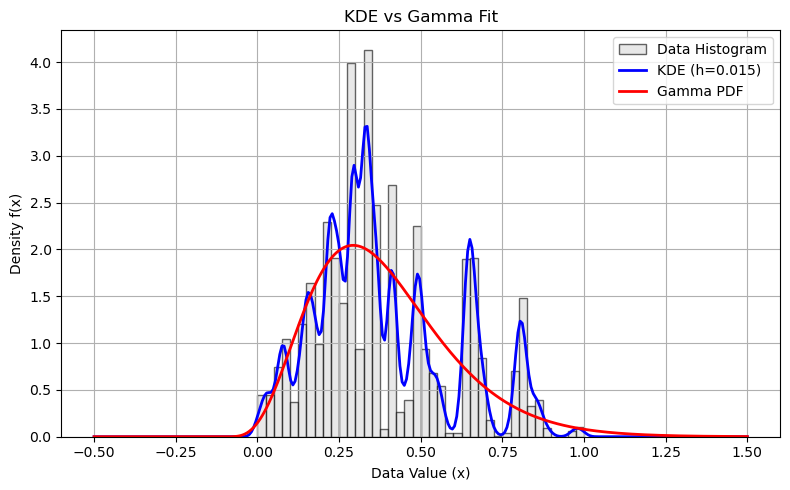

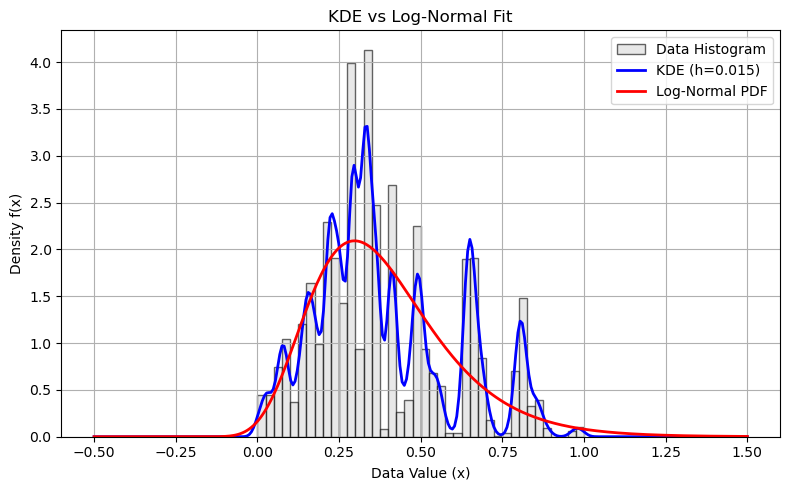

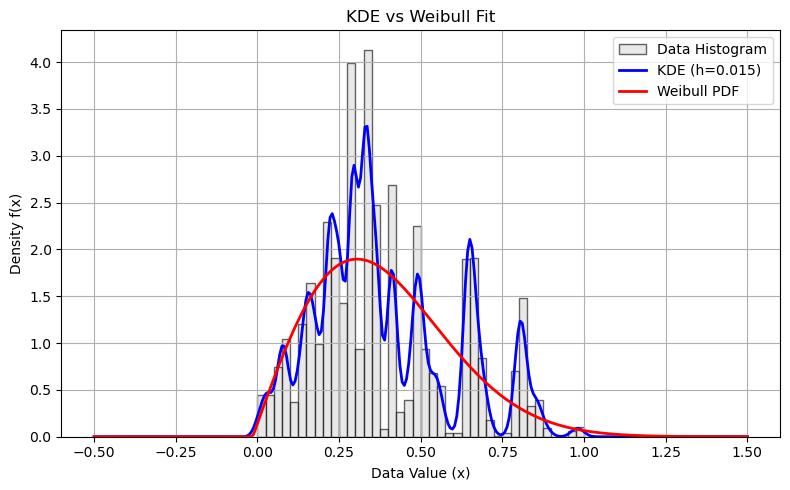

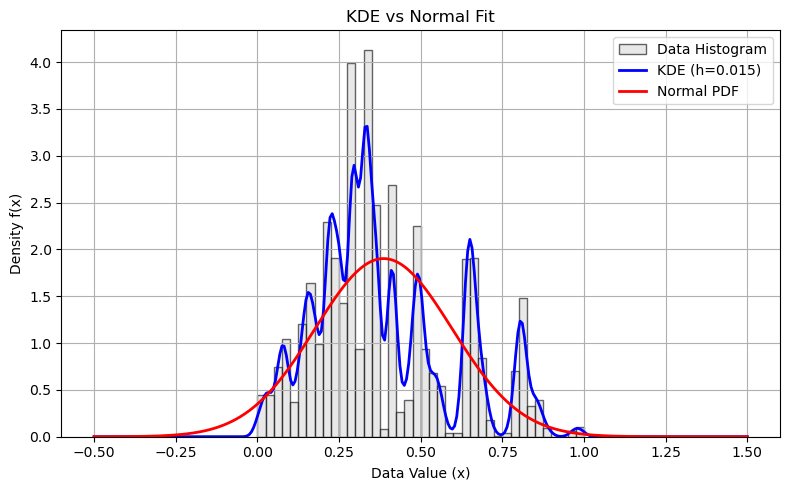

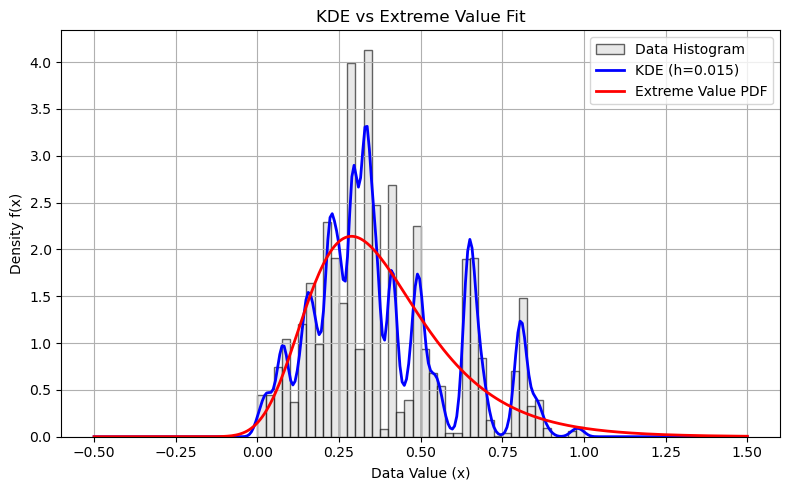

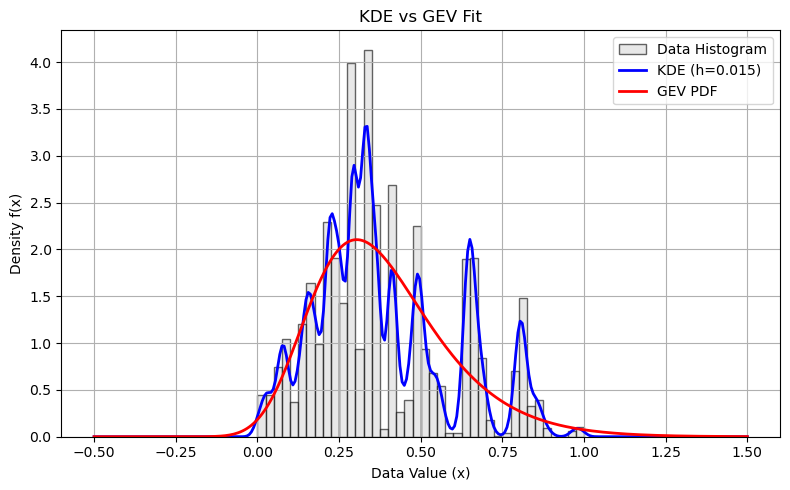

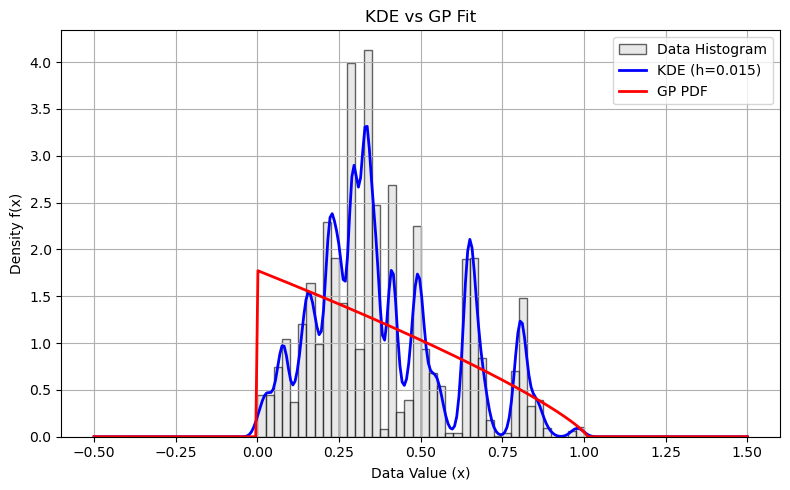


Valid distributions plotted individually:
  ✅ Gamma
  ✅ Log-Normal
  ✅ Weibull
  ✅ Normal
  ✅ Extreme Value
  ✅ GEV
  ✅ GP


In [60]:
# --- 4. Plot results (one figure per distribution) ---
for name, pdf in fitted_pdfs.items():
    plt.figure(figsize=(8, 5))
    
    # Histogram of data
    plt.hist(Data, bins=40, density=True, color=[0.85, 0.85, 0.85],
             edgecolor="k", alpha=0.6, label="Data Histogram")
    
    # KDE curve
    plt.plot(x_plot, f_kde, "b-", lw=2, label=f"KDE (h={h_AMISE:.3f})")
    
    # Fitted distribution
    plt.plot(x_plot, pdf, "r-", lw=2, label=f"{name} PDF")
    
    plt.title(f"KDE vs {name} Fit")
    plt.xlabel("Data Value (x)")
    plt.ylabel("Density f(x)")
    plt.legend(loc="best")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

print("\nValid distributions plotted individually:")
for name in fitted_pdfs.keys():
    print("  ✅", name)

Across all criterion ICOMP, AIC, and SBC, the GEV (Generalized Extreme Value) distribution is the best fit for the normalized black fiday purchase data set. Thus, ξ> 0, it has a long right tail and the data has large extremes clustered near the upper normalized bound. 

In [84]:
#Second data set, Dr. Bozdogon's data set
df = pd.read_excel('/Users/graysonpettit/Downloads/Major Course work: Materials/Project 1 Stat 563/STAT 563 LAB PROJECT#1 FALL_2025 WRITE UP CANVAS/MATLAB MODULES FOR STAT563 PROJECT#1_FALL_2025/Raw_Project_Data.xlsx')
data = df.astype(float).to_numpy()
print("raw head:", data[:5])
obs = len(data)
print("Observations:", obs)

# ---------------------------
# Normalize (min-max) and prepare log data safely
# ---------------------------
eps = 1e-8
normalized_data = (data - data.min()) / (data.max() - data.min())
# Ensure strictly positive for log/lognormal by adding tiny eps where necessary
normalized_pos = np.clip(normalized_data, eps, None)
logDATA = np.log(normalized_pos)

raw head: [[ 1.60752139]
 [10.98460652]
 [ 4.25231473]
 [ 5.44162772]
 [ 9.76187173]]
Observations: 499


Mean: 0.2684150433585319 Std: 0.1770701326716358 Var: 0.0313538318843507 Kurtosis: [0.8775945] min: [0.] max: [1.]
Optimal bandwidth: 0.05111227403406529


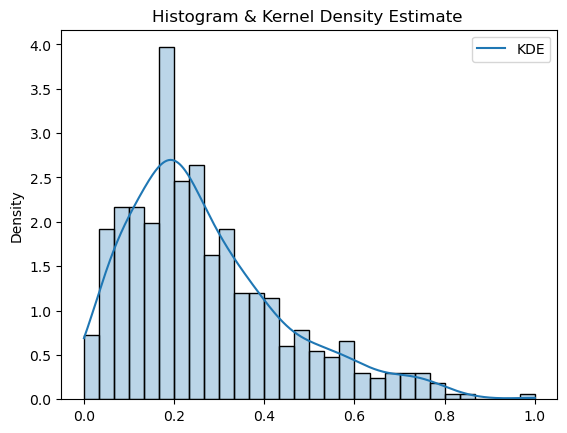

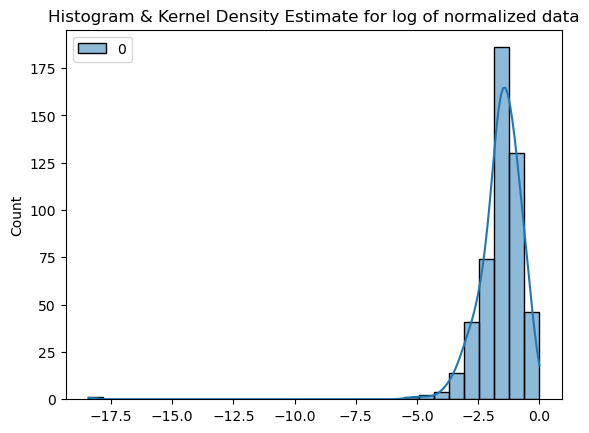

In [86]:
# Compute summary statistics
mu_data = normalized_data.mean()
var_data = normalized_data.var(ddof=1)
std_data = normalized_data.std(ddof=1)
kurt_val = kurtosis(normalized_data, fisher=True)
min_val= min(normalized_data)
max_val=max(normalized_data)

print("Mean:", mu_data, "Std:", std_data, "Var:", var_data, "Kurtosis:", kurt_val, "min:", min_val, "max:", max_val)
# --- KDE estimation ---
# gaussian_kde expects shape (num_features, num_samples)
normalized_data = np.array(normalized_data).flatten()
kde = gaussian_kde(normalized_data.reshape(1, -1))

# Extract optimal bandwidth
h = kde.factor * np.std(normalized_data, ddof=1)
print("Optimal bandwidth:", h)

# --- Plot the KDE curve ---
x_grid = np.linspace(0, 1, 500)
plt.plot(x_grid, kde(x_grid), label="KDE")
sns.histplot(normalized_data, bins=30, kde=False, stat='density', alpha=0.3)
plt.legend()
plt.title("Histogram & Kernel Density Estimate ")
plt.show()

sns.histplot(logDATA, bins=30, kde=True)
plt.title("Histogram & Kernel Density Estimate for log of normalized data")
plt.show()

The distribution is right skewed, the lower bound is 0 the upper bound is 1. This has a long tail on the right. 

In [88]:
# ---------------------------
# Run fits
# ---------------------------
Results = pd.DataFrame(columns=["Model", "AIC", "SBC", "ICOMP_F", "L_max"])
for name, logL, theta0, bounds in zip(model_names, logL_funcs, theta_initials, bounds_list):
    AIC, SBC, ICOMP_F, theta_hat, L_max = fit_and_select_pdf(normalized_pos, logL, theta0, bounds, name)
    Results.loc[len(Results)] = [name, AIC, SBC, ICOMP_F, L_max]

print("\nSummary results:")
print(Results)


--- Results for Gamma ---
  Parameters (m): 2
  Theta_hat: [1.934407 0.138758]
  Log-Likelihood (L_max): 210.392961
  AIC: -416.785922
  SBC: -408.360710
  ICOMP_F: -420.2859260897942

--- Results for Log-Normal ---
  Parameters (m): 2
  Theta_hat: [-1.595434  1.083245]
  Log-Likelihood (L_max): 48.170689
  AIC: -92.341378
  SBC: -83.916166
  ICOMP_F: -95.8944920286741

--- Results for Weibull ---
  Parameters (m): 2
  Theta_hat: [0.297182 1.529318]
  Log-Likelihood (L_max): 217.573968
  AIC: -431.147935
  SBC: -422.722723
  ICOMP_F: -434.67439562104613

--- Results for Normal ---
  Parameters (m): 2
  Theta_hat: [0.268415 0.176893]
  Log-Likelihood (L_max): 156.323662
  AIC: -308.647324
  SBC: -300.222111
  ICOMP_F: -312.25191886622054

--- Results for Extreme Value ---
  Parameters (m): 2
  Theta_hat: [0.189338 0.131433]
  Log-Likelihood (L_max): 213.373630
  AIC: -422.747261
  SBC: -414.322049
  ICOMP_F: -426.7419382493284

--- Results for GEV ---
  Parameters (m): 3
  Theta_hat: [

/opt/anaconda3/lib/python3.12/site-packages/scipy/optimize/_numdiff.py:596: RuntimeWarning: invalid value encountered in subtract
  df = fun(x1) - f0


Across all criterion ICOMP, AIC, and SBC, the Weibull distribution is the best fit for the normalized random data set that we were given. It has a long right tail. The mean is .27, the standard deviation is .18, the variance is .03, the Kurtosis is .88. The optimal bandwidth is .05, the upper bound is 1 and the lower bound is 0. It has a kind of heavy right tail, but it's not crazy. 

In [90]:
# Data: ensure a (N,1) shaped numpy array
X = np.array(normalized_data).reshape(-1, 1)
N = X.shape[0]
std_data = X.std(ddof=1)

kde = gaussian_kde(X.squeeze(), bw_method='silverman')
print("Silverman bandwidth:", kde.factor * X.std())


# Rule-of-thumb initial bandwidth
h0 = std_data * (4 / (3 * N)) ** (1 / 5)
print("h0 (rule-of-thumb):", h0)

Silverman bandwidth: 0.05408506418666433
h0 (rule-of-thumb): 0.054139339227102116



FAST KDE Hybrid Scoring Results:
  Optimal Bandwidth (h_CVLL): 0.0054
  CV Log-Likelihood (L_max proxy): 269.7931

Hybrid Information Criteria Scores (Lower is Better):
  AIC Hybrid:   -535.5863
  SBC Hybrid:   -527.1611
  ICOMP_F Hybrid: -539.1973


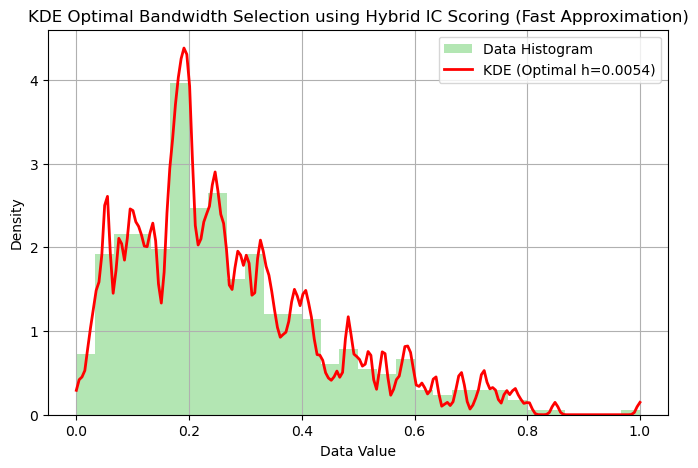

In [92]:

# Use your normalized data
Data = np.array(normalized_data).flatten()
N = len(Data)
std_data = np.std(Data, ddof=1)
mu_data = np.mean(Data)

# -----------------------------------------------------------
# FAST approximate CVLL function (no full leave-one-out loop)
# -----------------------------------------------------------

def fast_neg_cvll(h, data):
    """Approximate cross-validated log-likelihood for Gaussian KDE."""
    if h <= 0:
        return np.inf
    kde = gaussian_kde(data, bw_method=h / np.std(data, ddof=1))
    pdf_vals = kde.evaluate(data)
    # Avoid log(0)
    pdf_vals = np.clip(pdf_vals, 1e-12, None)
    return -np.sum(np.log(pdf_vals))  # negative log-likelihood to minimize


# Initial rule-of-thumb bandwidth
h0 = std_data * (4 / (3 * N)) ** (1 / 5)

# Minimize negative CVLL (bounded scalar optimization)
res = minimize_scalar(fast_neg_cvll, bounds=(h0 / 10, h0 * 10), args=(Data,), method="bounded")
h_opt_cvll = res.x
CVLL_max = -res.fun
m = 2

print("\nFAST KDE Hybrid Scoring Results:")
print(f"  Optimal Bandwidth (h_CVLL): {h_opt_cvll:.4f}")
print(f"  CV Log-Likelihood (L_max proxy): {CVLL_max:.4f}")

# -----------------------------------------------------------
# Hybrid Information Criteria
# -----------------------------------------------------------

AIC_hybrid = -2 * CVLL_max + 2 * m
SBC_hybrid = -2 * CVLL_max + m * np.log(N)

sigma_hat = std_data
Sigma_hat = (1 / N) * np.array([[sigma_hat**2, 0], [0, 2 * sigma_hat**4]])

eigen_Sigma = eigvals(Sigma_hat)
mean_eigen = np.mean(eigen_Sigma)
C1F_penalty = (1 / (4 * mean_eigen**2)) * np.sum((eigen_Sigma - mean_eigen) ** 2)
ICOMP_F_hybrid = -2 * CVLL_max + C1F_penalty

print("\nHybrid Information Criteria Scores (Lower is Better):")
print(f"  AIC Hybrid:   {AIC_hybrid:.4f}")
print(f"  SBC Hybrid:   {SBC_hybrid:.4f}")
print(f"  ICOMP_F Hybrid: {ICOMP_F_hybrid:.4f}")

# -----------------------------------------------------------
# Plot
# -----------------------------------------------------------

plt.figure(figsize=(8, 5))
plt.hist(Data, bins=30, density=True, color=(0.7, 0.9, 0.7), label="Data Histogram")

x_plot = np.linspace(np.min(Data), np.max(Data), 200)
kde_opt = gaussian_kde(Data, bw_method=h_opt_cvll / np.std(Data, ddof=1))
f_cvll = kde_opt.evaluate(x_plot)

plt.plot(x_plot, f_cvll, 'r-', linewidth=2, label=f'KDE (Optimal h={h_opt_cvll:.4f})')
plt.title("KDE Optimal Bandwidth Selection using Hybrid IC Scoring (Fast Approximation)")
plt.xlabel("Data Value")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.show()



KDE Bandwidth Estimation:
  Robust Sigma Estimate: 0.1594
  Optimal Bandwidth (h_AMISE): 0.0487


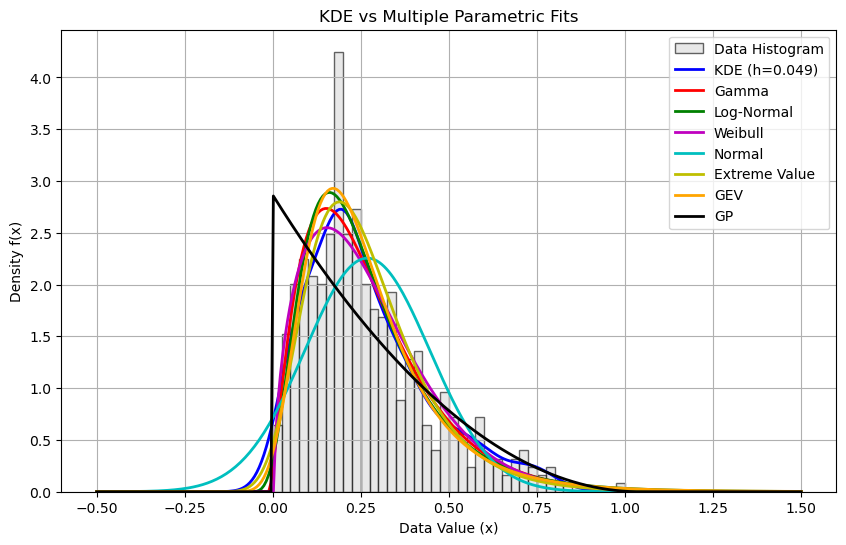


Valid distributions plotted:
  ✅ Gamma
  ✅ Log-Normal
  ✅ Weibull
  ✅ Normal
  ✅ Extreme Value
  ✅ GEV
  ✅ GP


In [42]:
# --- 0. Load or use your data ---
# Replace this line with your real dataset
Data = np.array(normalized_data).flatten()
Data = Data[~np.isnan(Data)]  # clean just in case
N = len(Data)

# --- 1. Compute robust bandwidth (AMISE rule) ---
sigma_data = np.std(Data, ddof=1)
IQR_data = iqr(Data)
sigma_robust = min(sigma_data, IQR_data / 1.349)
h_AMISE = sigma_robust * (4 / (3 * N)) ** (1 / 5)

print("\nKDE Bandwidth Estimation:")
print(f"  Robust Sigma Estimate: {sigma_robust:.4f}")
print(f"  Optimal Bandwidth (h_AMISE): {h_AMISE:.4f}")

# KDE estimation
x_plot = np.linspace(np.min(Data) - 0.5, np.max(Data) + 0.5, 300).reshape(-1, 1)
kde = KernelDensity(kernel="gaussian", bandwidth=h_AMISE).fit(Data.reshape(-1, 1))
f_kde = np.exp(kde.score_samples(x_plot))

# --- 2. Define supported distributions ---
distributions = {
    "Gamma": gamma,
    "Log-Normal": lognorm,
    "Weibull": weibull_min,
    "Normal": norm,
    "Extreme Value": gumbel_r,     # equivalent to MATLAB’s 'Extreme Value'
    "GEV": genextreme,
    "GP": genpareto
}

# --- 3. Fit and evaluate all distributions ---
fitted_pdfs = {}

for name, dist in distributions.items():
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")

            # Fit distribution parameters via MLE
            params = dist.fit(Data)
            pdf = dist.pdf(x_plot.flatten(), *params)

            # Check for NaN or Inf
            if np.any(np.isnan(pdf)) or np.any(np.isinf(pdf)):
                print(f"⚠️  {name} PDF returned NaN/Inf — skipping.")
                continue

            # Store only valid PDFs
            fitted_pdfs[name] = pdf

    except Exception as e:
        print(f"⚠️  Skipping {name}: {e}")
        continue

# --- 4. Plot results ---
plt.figure(figsize=(10, 6))
plt.hist(Data, bins=40, density=True, color=[0.85, 0.85, 0.85],
         edgecolor="k", alpha=0.6, label="Data Histogram")

plt.plot(x_plot, f_kde, "b-", lw=2, label=f"KDE (h={h_AMISE:.3f})")

# Plot each valid fitted distribution
colors = ["r", "g", "m", "c", "y", "orange", "k"]
for (name, pdf), c in zip(fitted_pdfs.items(), colors):
    plt.plot(x_plot, pdf, lw=2, label=name, color=c)

plt.title("KDE vs Multiple Parametric Fits")
plt.xlabel("Data Value (x)")
plt.ylabel("Density f(x)")
plt.legend(loc="best")
plt.grid(True)
plt.show()

print("\nValid distributions plotted:")
for name in fitted_pdfs.keys():
    print("  ✅", name)

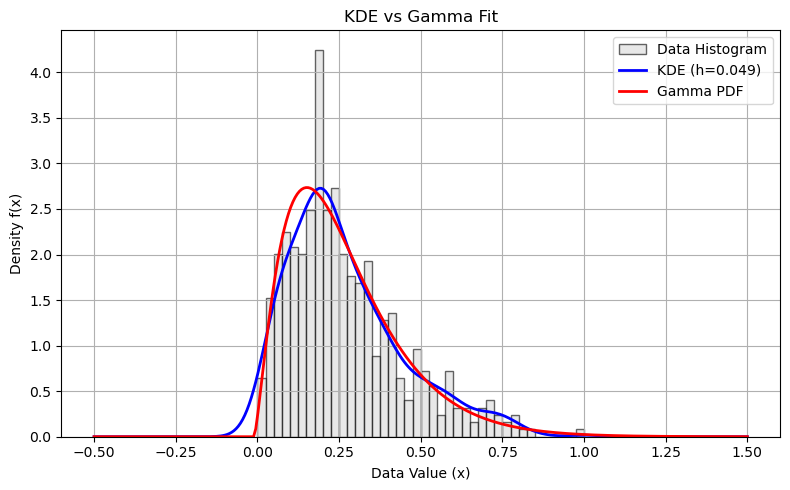

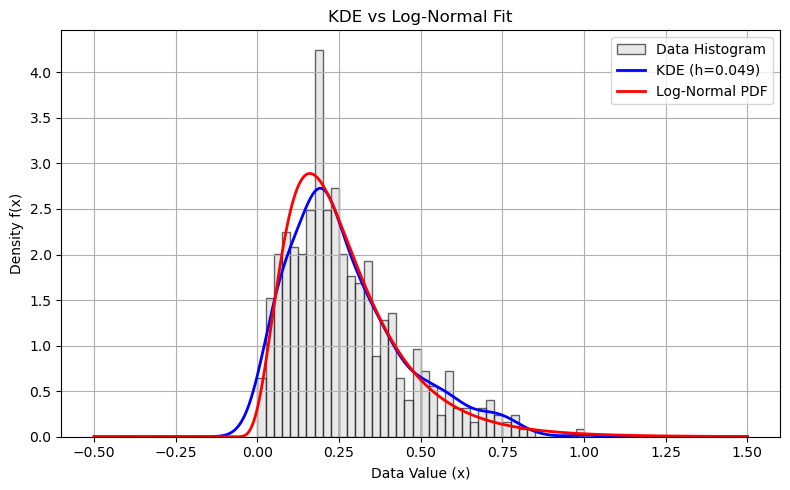

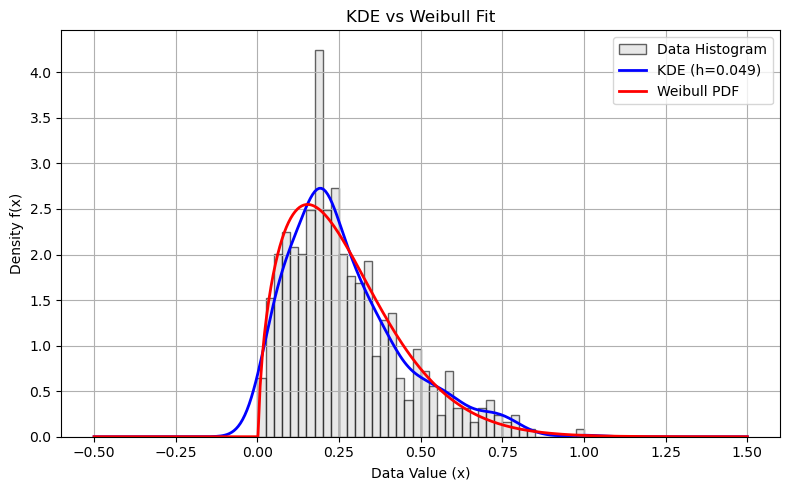

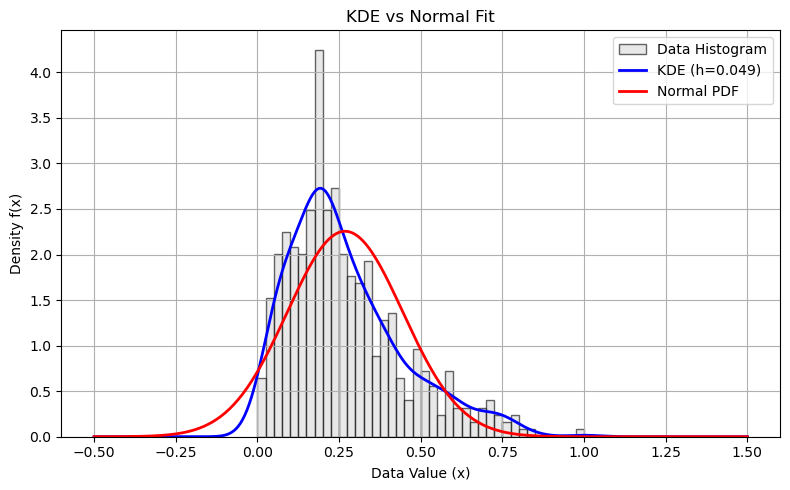

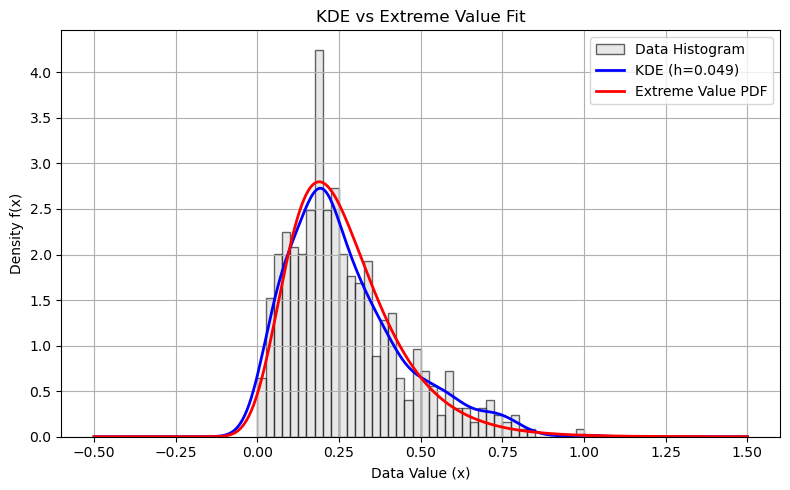

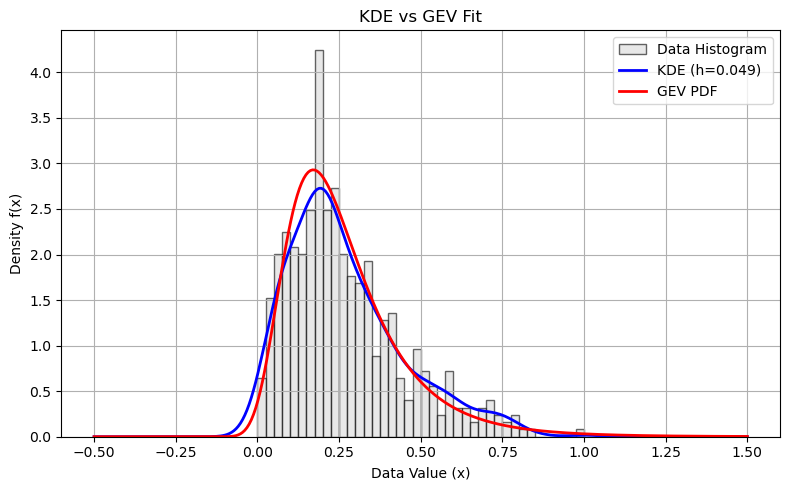

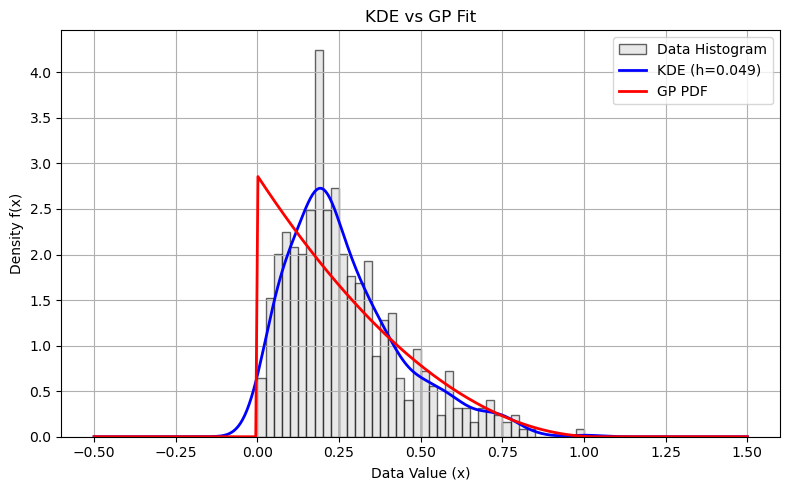


Valid distributions plotted individually:
  ✅ Gamma
  ✅ Log-Normal
  ✅ Weibull
  ✅ Normal
  ✅ Extreme Value
  ✅ GEV
  ✅ GP


In [44]:
# --- 4. Plot results (one figure per distribution) ---
for name, pdf in fitted_pdfs.items():
    plt.figure(figsize=(8, 5))
    
    # Histogram of data
    plt.hist(Data, bins=40, density=True, color=[0.85, 0.85, 0.85],
             edgecolor="k", alpha=0.6, label="Data Histogram")
    
    # KDE curve
    plt.plot(x_plot, f_kde, "b-", lw=2, label=f"KDE (h={h_AMISE:.3f})")
    
    # Fitted distribution
    plt.plot(x_plot, pdf, "r-", lw=2, label=f"{name} PDF")
    
    plt.title(f"KDE vs {name} Fit")
    plt.xlabel("Data Value (x)")
    plt.ylabel("Density f(x)")
    plt.legend(loc="best")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

print("\nValid distributions plotted individually:")
for name in fitted_pdfs.keys():
    print("  ✅", name)